In [1]:
# 2. Install dependencies (Modern versions for Python 3.12)
!pip install transformers==4.35.2
!pip install bitsandbytes accelerate shortuuid hf_transfer einops peft
!pip install salesforce-lavis --no-deps
!pip install contexttimer decord fairscale==0.4.4 ftfy iopath opendatasets
!pip install pycocoevalcap python-magic webdataset

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.5/123.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 69.3 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 107.4 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of

In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.0 MB/s eta 0:00:00a 0:00:01


In [21]:
import torch
import gc

# Xóa các biến mô hình (thay tên 'model' bằng tên biến LLaVA của bạn)
if 'model' in locals(): del model
if 'tokenizer' in locals(): del tokenizer

# Giải phóng bộ nhớ đệm
gc.collect()
torch.cuda.empty_cache()

📦 Loading YOLOv10s on cuda:0...
✅ Detector Ready!
🚀 Processing 1000 images...


100%|██████████| 1000/1000 [00:57<00:00, 17.29it/s]



✅ Đã lưu Inventory của 1000 ảnh vào: /kaggle/working/yolo_inventory_results.json

📊 THỐNG KÊ:
- Tổng ảnh test: 1000
- Số ảnh bị ảo giác (YOLO thấy thừa): 487
- Tỉ lệ khớp sạch: 51.30%


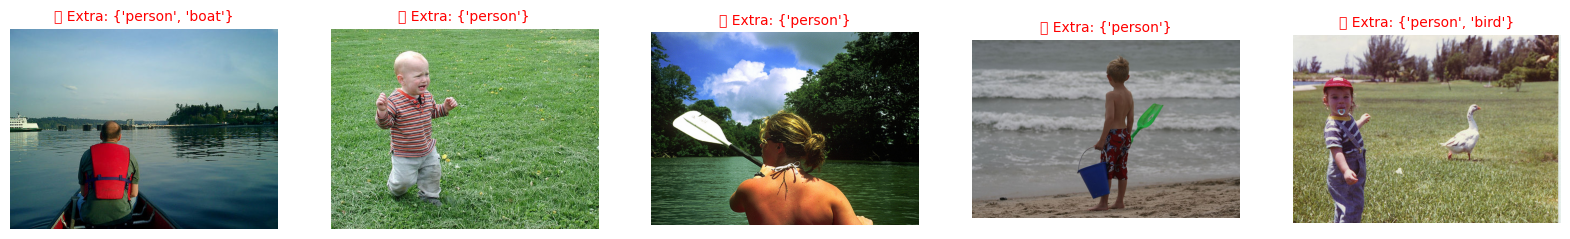

In [6]:
import json
import os
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from ultralytics import YOLO
import torch

# --- CẤU HÌNH ĐƯỜNG DẪN ---
IMAGE_DIR = "/kaggle/input/datasets/thomasandersona19/amber-dataset/images/"
GT_FILE = "/kaggle/input/datasets/thomasandersona19/amber-dataset/annotations.json" 
OUTPUT_INVENTORY_FILE = "/kaggle/working/yolo_inventory_results.json" # File lưu kết quả
NUM_TEST = 1000 

class YOLOInventoryDetector:
    def __init__(self, model_id="yolov10s.pt", device="cuda:0", confidence_threshold=0.3):
        self.device = device
        self.threshold = confidence_threshold
        print(f"📦 Loading YOLOv10s on {device}...")
        self.model = YOLO(model_id).to(self.device)
        print("✅ Detector Ready!")

    def get_inventory(self, image: Image.Image) -> list:
        results = self.model.predict(source=image, conf=self.threshold, device=self.device, verbose=False)
        detected_objects = []
        for r in results:
            for c in r.boxes.cls:
                obj_name = self.model.names[int(c)]
                detected_objects.append(obj_name.lower())
        return list(set(detected_objects))

# 1. Khởi tạo
detector = YOLOInventoryDetector(device="cuda:0") # Dùng cuda:0 nếu chưa load LLaVA

# 2. Load Ground Truth
with open(GT_FILE, 'r') as f:
    gt_data = json.load(f)

gt_map = {}
for item in gt_data:
    objects = [obj.lower().strip() for obj in item.get('truth', [])]
    img_filename = f"AMBER_{item['id']}.jpg"
    gt_map[img_filename] = set(objects)

# 3. Chạy Test và Thu thập kết quả
all_results = [] # Mảng chứa kết quả để lưu file
hallucination_cases = []
stats = {"total": 0, "hallucinated_images": 0}

image_list = list(gt_map.keys())[:NUM_TEST]
print(f"🚀 Processing {len(image_list)} images...")

for img_name in tqdm(image_list):
    img_path = os.path.join(IMAGE_DIR, img_name)
    if not os.path.exists(img_path): continue
    
    raw_image = Image.open(img_path).convert('RGB')
    inventory = detector.get_inventory(raw_image)
    
    # Lưu vào danh sách tổng
    all_results.append({
        "image": img_name,
        "yolo_inventory": inventory
    })
    
    # So sánh ảo giác để hiển thị
    yolo_objects = set(inventory)
    true_objects = gt_map[img_name]
    hallucinations = yolo_objects - true_objects
    
    stats["total"] += 1
    if hallucinations:
        stats["hallucinated_images"] += 1
        if len(hallucination_cases) < 5:
            hallucination_cases.append({
                "image": img_name, "img_path": img_path,
                "gt": true_objects, "yolo": yolo_objects,
                "hallucinated_items": hallucinations
            })

# 4. LƯU KẾT QUẢ RA FILE JSON
with open(OUTPUT_INVENTORY_FILE, 'w', encoding='utf-8') as f:
    json.dump(all_results, f, indent=4, ensure_ascii=False)

print(f"\n✅ Đã lưu Inventory của {len(all_results)} ảnh vào: {OUTPUT_INVENTORY_FILE}")

# 5. Hiển thị Thống kê & Ảnh minh họa
print(f"\n📊 THỐNG KÊ:")
print(f"- Tổng ảnh test: {stats['total']}")
print(f"- Số ảnh bị ảo giác (YOLO thấy thừa): {stats['hallucinated_images']}")
print(f"- Tỉ lệ khớp sạch: {((stats['total']-stats['hallucinated_images'])/stats['total'])*100:.2f}%")

if hallucination_cases:
    plt.figure(figsize=(20, 10))
    for i, case in enumerate(hallucination_cases):
        plt.subplot(1, 5, i + 1)
        plt.imshow(Image.open(case['img_path']))
        plt.title(f"🚨 Extra: {case['hallucinated_items']}", color='red', fontsize=10)
        plt.axis('off')
    plt.show()